alpha=0.000, I(S;W)=0.0000 nats, sqrt(2I/m)=0.0000, |gap|=0.0167,  ratio=376662.851
alpha=0.125, I(S;W)=0.1161 nats, sqrt(2I/m)=0.2155, |gap|=0.0452,  ratio=0.210
alpha=0.250, I(S;W)=0.3534 nats, sqrt(2I/m)=0.3760, |gap|=0.1078,  ratio=0.287
alpha=0.375, I(S;W)=0.6413 nats, sqrt(2I/m)=0.5065, |gap|=0.1352,  ratio=0.267
alpha=0.500, I(S;W)=1.0084 nats, sqrt(2I/m)=0.6351, |gap|=0.2196,  ratio=0.346
alpha=0.625, I(S;W)=1.3826 nats, sqrt(2I/m)=0.7437, |gap|=0.2779,  ratio=0.374
alpha=0.750, I(S;W)=1.8167 nats, sqrt(2I/m)=0.8525, |gap|=0.2868,  ratio=0.336
alpha=0.875, I(S;W)=2.3640 nats, sqrt(2I/m)=0.9724, |gap|=0.3460,  ratio=0.356
alpha=1.000, I(S;W)=2.7555 nats, sqrt(2I/m)=1.0499, |gap|=0.3961,  ratio=0.377


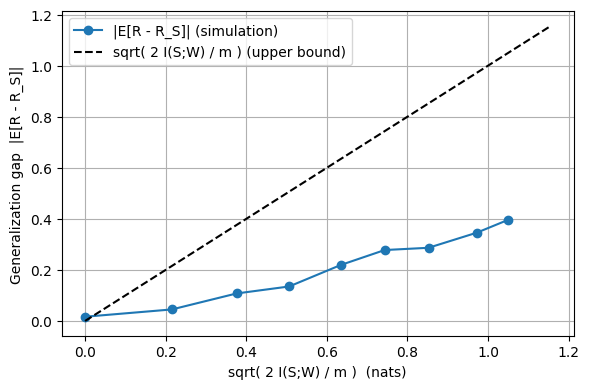

In [ ]:


import numpy as np
import math
import matplotlib.pyplot as plt


plt.rcParams.update({
    "text.usetex": False,
})


def logistic(x):
    return 1.0 / (1.0 + np.exp(-x))

def softmax_vec(logits):
    logits = np.array(logits, dtype=float)
    m = logits.max()
    exps = np.exp(logits - m)
    return exps / exps.sum()

def init_true_moe(num_experts=3, d=3, scale=1.0, rng=None):
    """Draw a single 'true' MoE model used to generate data."""
    if rng is None:
        rng = np.random.default_rng()
    V_true = rng.normal(scale=scale, size=(num_experts, d))
    W_true = rng.normal(scale=scale, size=(num_experts, d))
    return (V_true, W_true)


def init_candidate_moe_models(num_models=30, num_experts=3, d=3,
                              scale=1.0, rng=None):
    """
    Draw a collection of candidate MoE models {W_r}.
    All are i.i.d. from the same prior distribution.
    """
    if rng is None:
        rng = np.random.default_rng()

    models = []
    for _ in range(num_models):
        V = rng.normal(scale=scale, size=(num_experts, d))
        W = rng.normal(scale=scale, size=(num_experts, d))
        models.append((V, W))

    return models


def sample_from_moe(model, n_samples, rng=None):
    """
    Sample (X, Y) from a MoE model:
      - X ~ N(0, I_d)
      - I drawn from softmax(V x)
      - Y from Bernoulli( logistic( W_I x ) )
    """
    if rng is None:
        rng = np.random.default_rng()

    V, W = model
    num_experts, d = V.shape

    X = rng.normal(size=(n_samples, d))
    Y = np.zeros(n_samples, dtype=int)

    for j in range(n_samples):
        x = X[j]
        gating_probs = softmax_vec(V @ x)
        i = rng.choice(num_experts, p=gating_probs)
        p1 = logistic(W[i] @ x)
        Y[j] = rng.random() < p1

    return X, Y


def p_y1_given_x(model, x):
    """Mixture probability P(Y=1 | x, model)."""
    V, W = model
    gating = softmax_vec(V @ x)
    probs_per_expert = logistic(W @ x)
    return float((gating * probs_per_expert).sum())


def empirical_risk_01(model, X, Y):
    """0-1 classification error on given dataset."""
    probs = np.array([p_y1_given_x(model, x) for x in X])
    yhat = (probs >= 0.5).astype(int)
    return np.mean(yhat != Y)


def simulate_for_alpha(
    alpha,
    models,
    true_model,
    m=5,
    n_datasets=100,
    n_test=1000,
    rng=None
):
    """
    For a given alpha ∈ [0,1], run many datasets and estimate:
      - mean generalization gap E[R(W) - R_S(W)]
      - mutual information I(S;W) (nats) via I = H(W) - H(W|S)

    Learning algorithm A_alpha:
      - For each dataset S:
          * Compute empirical risks R_S(W_r) for all candidate models r
          * Let r_best = argmin_r R_S(W_r)
          * Define q(W=r | S) = (1-alpha)/R + alpha * 1{r = r_best}
          * Sample W ~ q(·|S)
    """
    if rng is None:
        rng = np.random.default_rng()

    num_models = len(models)

    test_X, test_Y = sample_from_moe(true_model, n_test, rng=rng)

    gaps = []
    posteriors = []

    for _ in range(n_datasets):

        X, Y = sample_from_moe(true_model, m, rng=rng)

        risks = [empirical_risk_01(model, X, Y) for model in models]
        best_idx = int(np.argmin(risks))


        q = np.full(num_models, (1.0 - alpha) / num_models)
        q[best_idx] += alpha
        posteriors.append(q)

        chosen_idx = rng.choice(num_models, p=q)
        chosen_model = models[chosen_idx]

        R_emp = empirical_risk_01(chosen_model, X, Y)

        R_pop = empirical_risk_01(chosen_model, test_X, test_Y)

        gaps.append(R_pop - R_emp)

    gaps = np.array(gaps)
    posteriors = np.array(posteriors)
    p_marginal = posteriors.mean(axis=0)


    H_W = -sum(pr * math.log(pr) for pr in p_marginal if pr > 0.0)


    H_W_given_S = 0.0
    for q in posteriors:
        H_q = -sum(qi * math.log(qi) for qi in q if qi > 0.0)
        H_W_given_S += H_q
    H_W_given_S /= len(posteriors)

    I_SW = H_W - H_W_given_S  # nats

    gap_mean = float(np.mean(gaps))
    return gap_mean, I_SW


def run_moe_generalization_experiment(
    m=5,
    num_models=30,
    num_experts=3,
    d=3,
    base_scale=1.0,
    n_datasets=100,
    n_test=1000,
    rng_seed=2
):
    rng = np.random.default_rng(rng_seed)


    true_model = init_true_moe(
        num_experts=num_experts,
        d=d,
        scale=base_scale,
        rng=rng,
    )


    models = init_candidate_moe_models(
        num_models=num_models,
        num_experts=num_experts,
        d=d,
        scale=base_scale,
        rng=rng,
    )

    alphas = np.linspace(0.0, 1.0, 9)

    sqrt_term_list = []
    gap_list = []

    for alpha in alphas:
        gap_mean, I_SW = simulate_for_alpha(
            alpha,
            models,
            true_model,
            m=m,
            n_datasets=n_datasets,
            n_test=n_test,
            rng=rng,
        )
        sqrt_term = math.sqrt(2.0 * I_SW / m)
        gap_abs = abs(gap_mean)
        sqrt_term_list.append(sqrt_term)
        gap_list.append(gap_abs)

        ratio = gap_abs / sqrt_term if sqrt_term > 1e-8 else 0.0
        print(
            f"alpha={alpha:.3f}, I(S;W)={I_SW:.4f} nats, "
            f"sqrt(2I/m)={sqrt_term:.4f}, "
            f"|gap|={gap_abs:.4f},  ratio={ratio:.3f}"
        )

    sqrt_term_arr = np.array(sqrt_term_list)
    gap_arr = np.array(gap_list)

    idx = np.argsort(sqrt_term_arr)
    sqrt_term_arr = sqrt_term_arr[idx]
    gap_arr = gap_arr[idx]


    plt.figure(figsize=(6, 4))
    plt.plot(
        sqrt_term_arr,
        gap_arr,
        "o-",
        label="|E[R - R_S]| (simulation)",
    )


    xgrid = np.linspace(0, max(sqrt_term_arr) * 1.1, 200)
    plt.plot(
        xgrid,
        xgrid,
        "k--",
        label="sqrt( 2 I(S;W) / m ) (upper bound)",
    )

    plt.xlabel("sqrt( 2 I(S;W) / m )  (nats)")
    plt.ylabel("Generalization gap  |E[R - R_S]|")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()

    plt.savefig("theorem1_moe_simulation.eps", format="eps", bbox_inches="tight")

    plt.show()



run_moe_generalization_experiment(
    m=5,
    num_models=30,
    num_experts=10,
    d=3,
    base_scale=1.0,
    n_datasets=100,
    n_test=1000,
    rng_seed=2,
)
